# Análise Exploratória Inicial
Este notebook realiza um EDA básico sobre o dataset de cafés Arábica. Ele carrega os dados, inspeciona a estrutura, verifica valores nulos e duplicados, explora distribuições e classifica a qualidade do café.

In [14]:
import pandas as pd

df = pd.read_csv("../data/raw/arabica_coffee_full_table.csv")

print(df.shape)
df.head()

(1509, 42)


,coffee_id,Country_of_Origin,Farm_Name,Lot_Number,Mill,ICO_Number,Company,Altitude,Region,Producer,...,Color,Category_One_Defects,Category_Two_Defects,Quakers,Expiration,Certification_Body,Certification_Address,Certification_Contact,parsed_expiration,parsed_grading_date
0,#647123,Guatemala,san francisco cotzal,11/441/50,"inmobiliaria e inversiones dos mil, s.a.",11/441/50,"inmobiliaria e inversiones dos mil, s.a.",1600.0,quiche,san francisco cotzal,...,Green,0,1,3.0,June 22 2023,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2023-06-22,2022-06-22
1,#927000,Guatemala,San jose del lago,11/15/95,San jose del lago,11/15/95,"Peter Schoenfeld, S.A.",1600.0,Atitlán,"Cafetalera Paquim, S.A.",...,Green,0,2,1.0,April 16 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-04-16,2023-04-17
2,#902618,Guatemala,varias fincas,11/15/51,El Trèbol/Lìnea Gourmet,11/15/51,"Peter Schoenfeld, S.A.",1550.0,Oriente Santa rosa,varios productores,...,Green,0,2,1.0,March 21 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-03-21,2023-03-22
3,#781706,Guatemala,San jose del lago,11/15/96,San jose del lago,11/15/96,"Peter Schoenfeld, S.A.",1600.0,Atitlán,"Cafetalera Paquim, S.A.",...,Green,0,1,0.0,April 16 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-04-16,2023-04-17
4,#237025,Guatemala,Finca Alta Luz,11-63-657,NaN,11-63-657,"Retrillas del pacifico, s.a.",1350.0,Huehuetenango,Maria de los Angeles Perez,...,Green,0,5,1.0,April 25 2024,Asociacion Nacional Del Café,"5a Calle 0-50, Zona 14 Guatemala City, Guatema...",Brayan Cifuentes -,2024-04-25,2023-04-26


### Visão geral das colunas
Mostra informações sobre tipos de dados, valores não nulos e uso de memória no dataset.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1509 entries, 0 to 1508
Data columns (total 42 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   coffee_id              1509 non-null   str    
 1   Country_of_Origin      1508 non-null   str    
 2   Farm_Name              1151 non-null   str    
 3   Lot_Number             467 non-null    str    
 4   Mill                   1196 non-null   str    
 5   ICO_Number             1230 non-null   str    
 6   Company                1300 non-null   str    
 7   Altitude               1279 non-null   float64
 8   Region                 1450 non-null   str    
 9   Producer               1278 non-null   str    
 10  Number_of_Bags         1509 non-null   int64  
 11  Bag_Weight             1509 non-null   str    
 12  In_Country_Partner     1509 non-null   str    
 13  Harvest_Year           1462 non-null   str    
 14  Grading_Date           1509 non-null   str    
 15  Owner          

### Análise de valores ausentes
Calcula quantidade e percentual de valores nulos por coluna para identificar possíveis problemas de limpeza de dados.

In [16]:
nulos = pd.DataFrame({
    "Quantidade": df.isnull().sum(),
    "Percentual (%)": (df.isnull().mean()*100).round(2)
})

nulos = nulos[nulos["Quantidade"] > 0]
nulos.sort_values("Quantidade", ascending=False)

,Quantidade,Percentual (%)
Defects,1311,86.88
Status,1311,86.88
Lot_Number,1042,69.05
Farm_Name,358,23.72
Mill,313,20.74
ICO_Number,279,18.49
Color,267,17.69
Producer,231,15.31
Altitude,230,15.24
Company,209,13.85


### Verificação de duplicatas
Confirma se existem linhas duplicadas no dataset, o que pode distorcer a análise.

In [17]:
print(f"Duplicados: {df.duplicated().sum()}")

Duplicados: 0


### Estatísticas da pontuação total
Mostra medidas descritivas da coluna `Total_Cup_Points` para entender média, quartis e dispersão.


In [18]:
df["Total_Cup_Points"].describe()

count    1509.000000
mean       82.333612
std         3.378540
min         0.000000
25%        81.420000
50%        82.670000
75%        83.830000
max        90.580000
Name: Total_Cup_Points, dtype: float64

### Visualização da distribuição de pontuação
Plota um histograma para identificar a forma da distribuição das notas.


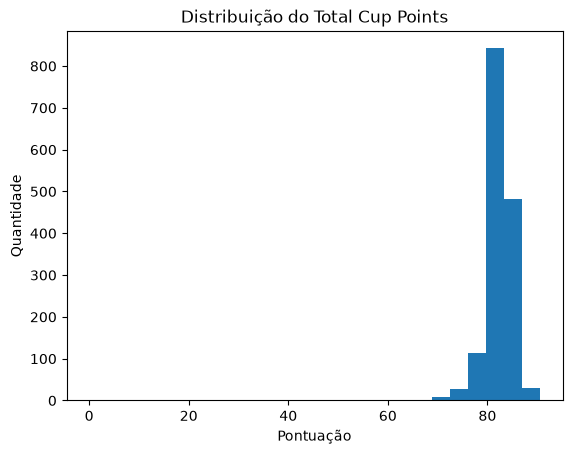

In [19]:
import matplotlib.pyplot as plt

plt.hist(df["Total_Cup_Points"], bins=25)
plt.title("Distribuição do Total Cup Points")
plt.xlabel("Pontuação")
plt.ylabel("Quantidade")
plt.show()

### Frequência por país de origem
Exibe quantos registros existem para cada país no dataset.


In [20]:
print(df["Country_of_Origin"].value_counts())

Country_of_Origin
Mexico                          240
Colombia                        202
Guatemala                       198
Brazil                          140
Taiwan                          136
United States (Hawaii)           78
Honduras                         63
Costa Rica                       59
Ethiopia                         55
Tanzania, United Republic Of     46
Thailand                         44
Nicaragua                        33
Uganda                           30
El Salvador                      27
Kenya                            27
Indonesia                        23
China                            16
Peru                             14
Vietnam                          11
Malawi                           11
Myanmar                           9
United States                     8
Philippines                       6
Haiti                             6
Laos                              6
Panama                            5
United States (Puerto Rico)       4
Burundi   

### Análise de países com poucos registros
Testa diferentes limites para saber quantos países teriam que ser agrupados em uma classe `Outros`.

In [21]:
contagem = df["Country_of_Origin"].value_counts()

for corte in [10,20,30,50]:
    raros = contagem[contagem < corte]

    print(
        f"Corte {corte}: "
        f"{len(raros)} países agrupados"
    )

Corte 10: 17 países agrupados
Corte 20: 21 países agrupados
Corte 30: 24 países agrupados
Corte 50: 28 países agrupados


### Contagem de categorias textuais
Mostra a distribuição de valores em colunas categóricas como variedade, método e cor.


In [22]:
categoricas = [
    "Variety",
    "Processing_Method",
    "Color"
]

for coluna in categoricas:
    print("="*40)
    print(coluna)
    print(df[coluna].value_counts())

Variety
Variety
Caturra                                                         280
Bourbon                                                         242
Typica                                                          235
Other                                                           108
Catuai                                                           83
Hawaiian Kona                                                    44
Gesha                                                            39
Yellow Bourbon                                                   38
Mundo Novo                                                       35
Catimor                                                          31
SL14                                                             21
SL28                                                             17
SL34                                                             16
Pacas                                                            14
unknown                         

### Estatísticas das variáveis numéricas
Apresenta medidas descritivas das variáveis numéricas selecionadas.


In [23]:
numericas = [
    "Moisture",
    "Category_One_Defects",
    "Category_Two_Defects",
    "Quakers",
    "Altitude"
]

df[numericas].describe()

,Moisture,Category_One_Defects,Category_Two_Defects,Quakers,Altitude
count,1509.000000,1509.000000,1509.000000,1508.000000,1279.000000
mean,0.091294,0.388999,3.396952,0.234085,1299.964261
std,0.045368,1.724503,5.115200,0.963283,423.674817
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.098000,0.000000,0.000000,0.000000,1100.000000
50%,0.110000,0.000000,2.000000,0.000000,1311.000000
75%,0.120000,0.000000,4.000000,0.000000,1600.000000
max,0.280000,31.000000,55.000000,11.000000,2560.000000


### Matriz de correlação
Visualiza a correlação entre as variáveis numéricas para detectar relações.


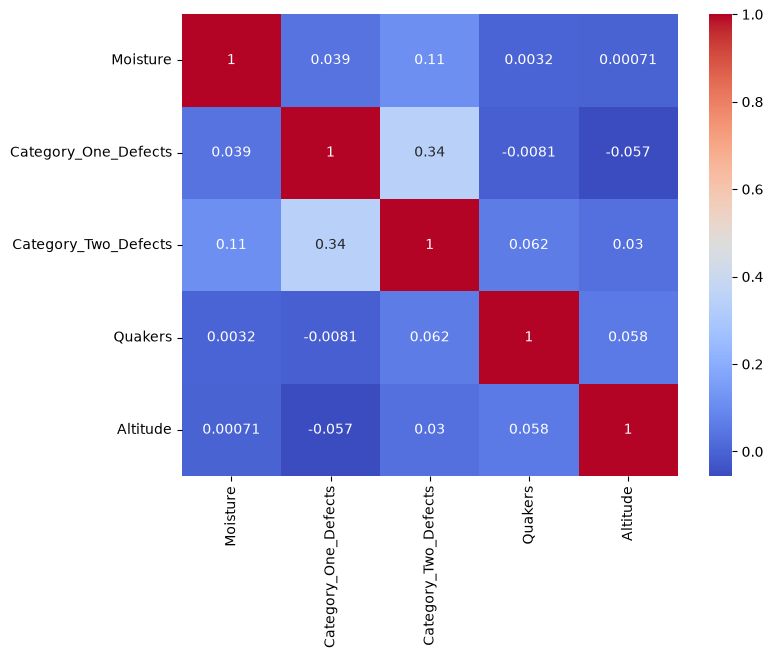

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numericas].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

### Boxplots das variáveis numéricas
Mostra a dispersão e os outliers de cada variável numérica.


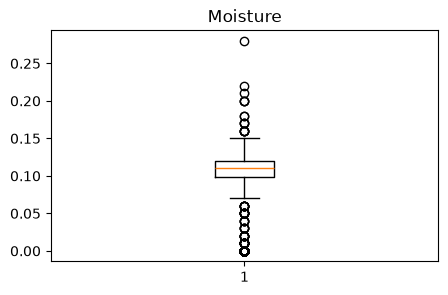

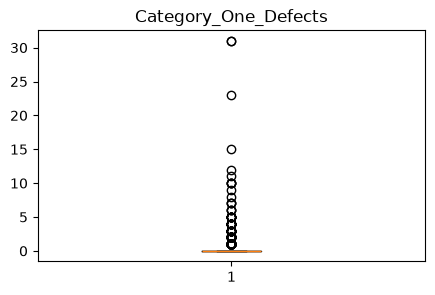

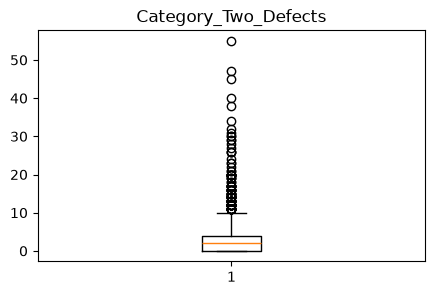

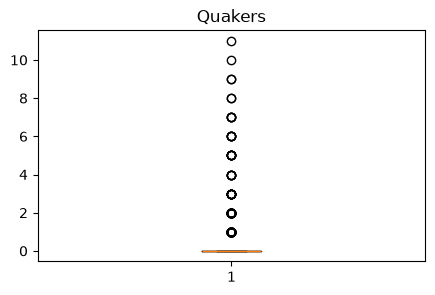

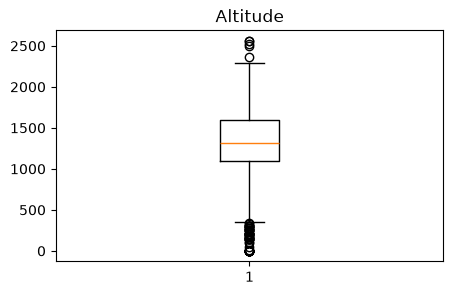

In [25]:
for coluna in numericas:

    plt.figure(figsize=(5,3))

    plt.boxplot(df[coluna].dropna())

    plt.title(coluna)

    plt.show()

### Criação de classes de qualidade
Define categorias de qualidade de café com base nos pontos totais.


In [26]:
def classificar(pontos):

    if pontos < 82.4:
        return "Tradicional"

    elif pontos < 84:
        return "Superior"

    else:
        return "Gourmet"

df["Classe"] = df["Total_Cup_Points"].apply(classificar)

df["Classe"].value_counts()

Classe
Tradicional    647
Superior       512
Gourmet        350
Name: count, dtype: int64